c:\DataThon\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000867 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1811
[LightGBM] [Info] Number of data points in the train set: 3287, number of used features: 13
[LightGBM] [Info] Start training from score 4417167.630657


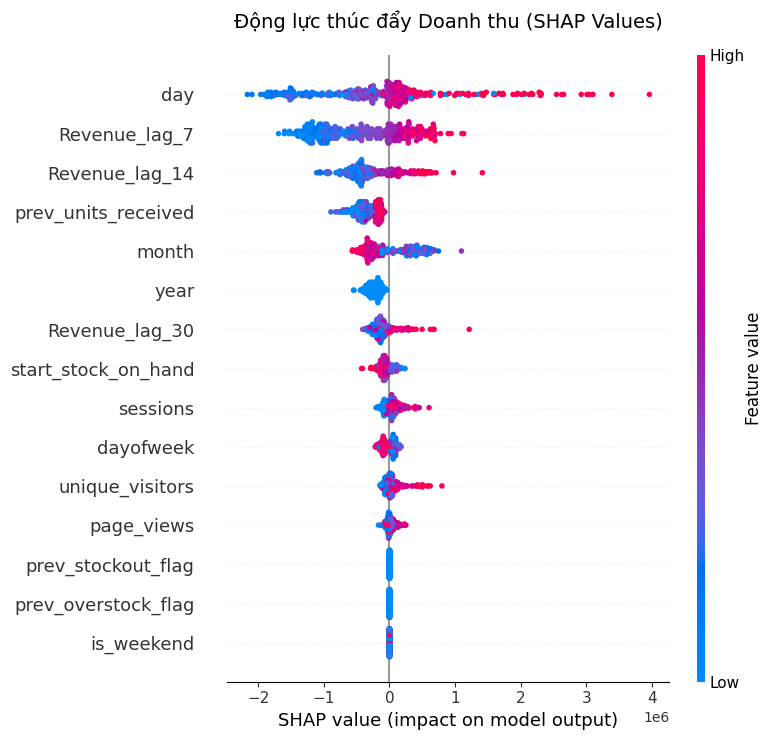

In [1]:
import pandas as pd
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt

# 1. Load dữ liệu đã qua xử lý
# (Giả định X_train, y_revenue_train, X_val đã được chuẩn bị từ pipeline)
X_train = pd.read_csv('../data/processed/X_train.csv')
y_revenue_train = pd.read_csv('../data/processed/y_revenue_train.csv')
X_val = pd.read_csv('../data/processed/X_val.csv')

# 2. Huấn luyện mô hình LightGBM cơ bản
model_revenue = lgb.LGBMRegressor(random_state=42)
model_revenue.fit(X_train, y_revenue_train)

# 3. Khởi tạo SHAP Explainer
explainer = shap.Explainer(model_revenue, X_train)
shap_values = explainer(X_val)

# 4. Trực quan hóa Feature Importance (Summary Plot)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_val, show=False)
plt.title('Động lực thúc đẩy Doanh thu (SHAP Values)', fontsize=14, pad=20)
plt.tight_layout()

# 5. Lưu ảnh chất lượng cao để chèn vào báo cáo LaTeX
plt.savefig('../reports/figures/shap_summary_revenue.png', dpi=300, bbox_inches='tight')
plt.show()